In [1]:
from scipy.optimize import brentq
import numpy as np
from datetime import datetime
import time, sys, os, pyvisa, subprocess
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import time

ploter_path = r"C:\Users\Crow108\Documents\GitHub\Simple_DAQ\Customized\SD_plot"
if ploter_path not in sys.path:
    sys.path.append(ploter_path)
from SD_plot_universal import *

In [2]:
def R2T_900(R):  # from 6K to 96K
    a0, a1, a2, a3, a4, a5, a6, a7, a8 = 6.75543700e+03, -1.59063022e+04, 1.92990842e+04, -1.30574569e+04, 5.39085191e+03, -1.39623593e+03, 2.22191016e+02, -1.99044732e+01, 7.69758689e-01
    
    if np.isscalar(R):
        R = np.array([R])

    if np.any(R < 946.97) or np.any(R > 1135.68):
        print('out of range: results may not be accurate')

    def f(T, R):
        log_T = np.log(T)
        return (a0 + a1 * log_T + a2 * log_T**2 + a3 * log_T**3 +
                a4 * log_T**4 + a5 * log_T**5 + a6 * log_T**6 +
                a7 * log_T**7 + a8 * log_T**8) - R

    def find_temp(R):
        try:
            return brentq(f, 0, 97, args=(R,))
        except ValueError:
            raise ValueError('root finding did not converge within the temperature range 6K to 96K')

    temperatures = np.array([find_temp(R_input) for R_input in R])
    
    if temperatures.size == 1:
        return temperatures[0]
    else:
        return temperatures

def getSpec(x, y, z, fixed_temp):
    
    # Filter the data for the fixed temperature
    mask = (y == fixed_temp)
    x_filtered = x[mask]
    z_filtered = z[mask]

    return x_filtered,z_filtered

def lorentzian(f, f0, gamma, A, yshift):
    return A / (1 + ((f - f0) / gamma) ** 2) + yshift

def fit_lorentzian(x, y, f0_guess, gamma_guess, A_guess, yshift_guess):
    # Fit the Lorentzian function to the data with bounds
    popt, _ = curve_fit(lorentzian, x, y, p0=[f0_guess, gamma_guess, A_guess, yshift_guess])
    return popt  # popt contains [f0, gamma, A, yshift]

def find_FWHM(freq, power_db):
    # Step 1: Identify the peak
    peak_index = np.argmax(power_db)
    peak_power = power_db[peak_index]
    peak_freq = freq[peak_index]

    # Define target power level (3 dB down)
    target_power = peak_power - 3

    # Step 2: Find the -3 dB points
    # Search left from the peak
    left_index = np.where(power_db[:peak_index] <= target_power)[0]
    if len(left_index) > 0:
        left_index = left_index[-1]  # The closest on the left
    else:
        left_index = peak_index  # If no point found, use the peak index

    # Search right from the peak
    right_index = np.where(power_db[peak_index:] <= target_power)[0]
    if len(right_index) > 0:
        right_index = right_index[0] + peak_index  # Adjust index because of slice
    else:
        right_index = peak_index  # If no point found, use the peak index

    # Step 3: Calculate Δf
    delta_f = freq[right_index] - freq[left_index]

    # Return the FWHM and the frequencies at -3 dB points
    return delta_f

def Q_n_f0_YS(freq, temp, S21):
    def get_spectrum(freq, temp, S21, fixed_temp):
        mask = (temp == fixed_temp)
        return freq[mask], S21[mask]

    temperatures = temp
    QFactor = []
    peak_frequencies = []

    for t in temperatures:
        freq_T, S21_T = get_spectrum(freq, temp, S21, fixed_temp=t)
        
        # Find the highest peak
        peaks, _ = find_peaks(S21_T)
        if len(peaks) == 0:
            continue  # Skip if no peaks are found

        highest_peak_idx = peaks[np.argmax(S21_T[peaks])]
        f0 = freq_T[highest_peak_idx]

        # Fit the Lorentzian within +-20 units around the peak
        fit_range_mask = (freq_T >= (f0 - 5)) & (freq_T <= (f0 + 5))
        fit_freq = freq_T[fit_range_mask]
        fit_S21 = S21_T[fit_range_mask]

        if len(fit_freq) < 3:  # Ensure enough data points for fitting
            continue
        
        try:
            # Provide reasonable initial guesses
            f0_guess = f0
            gamma_guess = 2.333
            A_guess = 15
            yshift_guess=-35
            f0_fit_0, gamma_fit_0, A_fit_0 , yshift_fit_0= fit_lorentzian(fit_freq, fit_S21, f0_guess, gamma_guess, A_guess, yshift_guess)
            f0_fit, gamma_fit, A_fit, yshift_fit= fit_lorentzian(fit_freq, fit_S21, f0_fit_0, gamma_fit_0, A_fit_0, yshift_fit_0)
            yaxis=A_fit / (1 + ((fit_freq - f0) /gamma_fit) ** 2)+ yshift_fit
            FWHM=find_FWHM(fit_freq,yaxis)
            if FWHM == 0:
                fit_range_mask = (freq_T >= (f0 - 20)) & (freq_T <= (f0 + 20))
                f0_fit_0, gamma_fit_0, A_fit_0 , yshift_fit_0= fit_lorentzian(fit_freq, fit_S21, f0_guess, gamma_guess, A_guess, yshift_guess)
                f0_fit, gamma_fit, A_fit, yshift_fit= fit_lorentzian(fit_freq, fit_S21, f0_fit_0, gamma_fit_0, A_fit_0, yshift_fit_0)
                yaxis=A_fit / (1 + ((fit_freq - f0) /gamma_fit) ** 2)+ yshift_fit
                FWHM=find_FWHM(fit_freq,yaxis)
            Q=f0/FWHM
            QFactor.append(Q)
            peak_frequencies.append(f0)
        except RuntimeError:
            continue  # Skip if the fitting fails

    return np.array(QFactor), np.array(peak_frequencies)

def getSpec(freq, temp, S21, fixed_temp):
    """
    Extracts frequency and S21 data for a specified temperature.

    Parameters:
    freq (np.ndarray): 1D array of frequency values.
    temp (np.ndarray): 1D array of temperature values.
    S21 (np.ndarray): 1D array of S21 transmission values.
    fixed_temp (float): The temperature value to fix.

    Returns:
    np.ndarray: Filtered frequency values corresponding to the fixed temperature.
    np.ndarray: Filtered S21 values corresponding to the fixed temperature.
    """
    # Create a mask that selects only the entries corresponding to the fixed temperature
    mask = (temp == fixed_temp)

    # Apply the mask to the frequency and S21 arrays to filter the data
    freq_filtered = freq[mask]
    S21_filtered = S21[mask]

    return freq_filtered, S21_filtered

w/o=1134.30 Ohm

In [3]:
R2T_900(1149.61)

out of range: results may not be accurate


C:\Users\Crow108\AppData\Local\Temp\ipykernel_10404\3807678656.py:11: RuntimeWarning: divide by zero encountered in log
  log_T = np.log(T)


4.447767032206453

In [83]:
R_thermo=np.array([1133.65, 1133.65, 1133.59, 1133.51, 1133.39, 1133.23, 1133.04, 1131.07, 1129.61, 1127.27, 1118.72])
V_mag=np.array([0.023, 0.055, 0.086, 0.117, 0.149, 0.182, 0.378, 0.476, 0.606, 0.971, 1.313])
I_mag=np.array([0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.012, 0.015, 0.019, 0.030, 0.040])


In [84]:
print(V_mag/I_mag)
print(R2T_900(R_thermo))

[23.         27.5        28.66666667 29.25       29.8        30.33333333
 31.5        31.73333333 31.89473684 32.36666667 32.825     ]
[6.0512978  6.0512978  6.0589933  6.06925634 6.08465553 6.10519536
 6.12959561 6.38264326 6.56953952 6.86689661 7.93263169]


C:\Users\Crow108\AppData\Local\Temp\ipykernel_18060\3807678656.py:11: RuntimeWarning: divide by zero encountered in log
  log_T = np.log(T)


In [ ]:
R2T_900(1022)

In [ ]:
date="20240809"
data_dir = r'C:\Users\Crow108\Documents\Data\YS\BSSCO_cooling_ICET\data'
folder_path = os.path.join(data_dir,date)
print(folder_path)

In [ ]:
data = load_data_from_folder(folder_path)

In [ ]:
R = data['R_RuOx']
timestamp = data['timestamp']
Vx = data['V_x']
Vy = data['V_y']

In [ ]:
mask = np.logical_and(R > 946.97,R < 1135.68)
temp = R2T_900(1135)
print(temp)

In [ ]:
plt.plot(timestamp,Vx)
plt.plot(timestamp[mask],Vx[mask],'r--')

In [ ]:
fig, ax = plt.subplots(figsize=(3, 2))  
plot_fill_matrix(freq,temp,S21,cmap='coolwarm',ax=None)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Temperature (K)")
cbar=plt.colorbar()
cbar.set_label("S21 (dB)")

In [ ]:
res_Q, res_f0 = Q_n_f0_YS(freq, temp, S21)

In [ ]:
plt.figure(figsize=(2, 1.3))
plt.plot(temp,res_f0)
plt.ylabel("Center Frequency (MHz)")
plt.xlabel("Temperature (K)")

In [ ]:
plt.figure(figsize=(2, 1.3))
plt.plot(temp,res_Q)
plt.ylabel("Quality Factor")
plt.xlabel("Temperature (K)")

In [ ]:
plt.figure(figsize=(2, 1.3))
plt.plot(temp,res_Q)
plt.ylabel("Quality Factor")
plt.xlabel("Temperature (K)")

## Individual Analysis ##

In [ ]:
temp_index=11
actual_index=temp_index*2001
freq_fixed,S21_fixed=getSpec(freq,temp,S21,fixed_temp=temp[actual_index])
T=round(temp[actual_index],4)
plt.plot(freq_fixed, S21_fixed, label=f"Temperature: {T} K") 
plt.legend()

In [ ]:
def lorentzian(f, f0, gamma, A, yshift):
    return A / (1 + ((f - f0) / gamma) ** 2) + yshift

def fit_lorentzian(x, y, f0_guess, gamma_guess, A_guess, yshift_guess):
    # Fit the Lorentzian function to the data with bounds
    popt, _ = curve_fit(lorentzian, x, y, p0=[f0_guess, gamma_guess, A_guess, yshift_guess])
    return popt  # popt contains [f0, gamma, A, yshift]

peaks, _ = find_peaks(S21_fixed)

highest_peak_idx = peaks[np.argmax(S21_fixed[peaks])]
f0 = freq_fixed[highest_peak_idx]

fit_range_mask = (freq_fixed >= (f0 - 5)) & (freq_fixed <= (f0 + 5.5))
fit_freq = freq_fixed[fit_range_mask]
fit_S21 = S21_fixed[fit_range_mask]

# Provide reasonable initial guesses
f0_guess = f0
gamma_guess = 2.333
A_guess = 15
yshift_guess=-35

f0_fit_0, gamma_fit_0, A_fit_0 , yshift_fit_0= fit_lorentzian(fit_freq, fit_S21, f0_guess, gamma_guess, A_guess, yshift_guess)
print(f"f0_fit: {f0_fit_0}, gamma_fit: {gamma_fit_0}, A_fit: {A_fit_0}, yshift_fit: {yshift_fit_0}")

f0_fit, gamma_fit, A_fit , yshift_fit= fit_lorentzian(fit_freq, fit_S21, f0_fit_0, gamma_fit_0, A_fit_0, yshift_fit_0)
print(f"f0_fit: {f0_fit}, gamma_fit: {gamma_fit}, A_fit: {A_fit}, yshift_fit: {yshift_fit}")



In [ ]:
yaxis=A_fit / (1 + ((fit_freq - f0_fit) /gamma_fit) ** 2)+ yshift_fit
plt.plot(fit_freq,yaxis,label=f"Temperature: {T} K")
plt.plot(fit_freq,fit_S21,color='r')

FWHM=find_FWHM(fit_freq,yaxis)

# plt.legend()

In [ ]:
print("Temperature =",round(temp[actual_index],4))
print("Q =",f0/FWHM)
print('f =',f0)

In [ ]:
#no peak @ 96 (equilibrate @ each T)
# TArray=np.array([96.3605,76.1644,67.7806,60.0942,54.8306,49.2845,43.4387,39.2429,35.0257,31.5831,28.4550,17.8323])
# QArray=np.array([0,404.2020,1078.7803,1157.8989,1160.8989,1163.2323,1344.2680,1345.4219,1346.4219,1459.2904,1592.4986,1753.3484])
# fArray=np.array([0,6787.3684,6900.9144,6944.0939,6962.0853,6976.0787,6987.0857,6992.9952,6998.0682,7001.2667,7003.6656,7010.0625])

In [ ]:
plt.plot(TempArray,QFactor)

## Looping Over all Temp ##

In [ ]:
iList=[]
qList=[]
fList=[]
tList=[]
for i in range(121):
    temp_index=i
    actual_index=temp_index*2001
    freq_fixed,S21_fixed=getSpec(freq,temp,S21,fixed_temp=temp[actual_index])
    T=round(temp[actual_index],4)
    # plt.plot(freq_fixed, S21_fixed, label=f"Temperature: {T} K") 
    # plt.legend()
    peaks, _ = find_peaks(S21_fixed)

    highest_peak_idx = peaks[np.argmax(S21_fixed[peaks])]
    f0 = freq_fixed[highest_peak_idx]

    fit_range_mask = (freq_fixed >= (f0 - 10)) & (freq_fixed <= (f0 + 10))
    fit_freq = freq_fixed[fit_range_mask]
    fit_S21 = S21_fixed[fit_range_mask]

    # Provide reasonable initial guesses
    f0_guess = f0
    gamma_guess = 2.333
    A_guess = 15
    yshift_guess=-35

    f0_fit_0, gamma_fit_0, A_fit_0 , yshift_fit_0= fit_lorentzian(fit_freq, fit_S21, f0_guess, gamma_guess, A_guess, yshift_guess)
    # print(f"f0_fit: {f0_fit_0}, gamma_fit: {gamma_fit_0}, A_fit: {A_fit_0}, yshift_fit: {yshift_fit_0}")

    f0_fit, gamma_fit, A_fit , yshift_fit= fit_lorentzian(fit_freq, fit_S21, f0_fit_0, gamma_fit_0, A_fit_0, yshift_fit_0)
    # print(f"f0_fit: {f0_fit}, gamma_fit: {gamma_fit}, A_fit: {A_fit}, yshift_fit: {yshift_fit}")

    yaxis=A_fit / (1 + ((fit_freq - f0_fit) /gamma_fit) ** 2)+ yshift_fit
    # plt.plot(fit_freq,yaxis,label=f"Temperature: {T} K")
    # plt.plot(fit_freq,fit_S21,color='r')
    
    # plt.show()

    FWHM=find_FWHM(fit_freq,yaxis)
    
    # print("Temperature =",round(temp[actual_index],2))
    # print("Q =",f0/FWHM)
    # print('f =',f0)
    # print('loop number =',i)
    if i==-1:
        QF,OmegaR,Tem=0,0,round(temp[actual_index],2)
    else:
        QF=f0/FWHM
        OmegaR=f0
        Tem=round(temp[actual_index],2)
    
    qList.append(QF)
    fList.append(OmegaR)
    tList.append(Tem)

    # if FWHM == 0:
    #     iList.append(i)

    # plt.clf()
    # plt.close()

    

In [ ]:
plt.plot(tList, qList, marker='o', markersize=5, linestyle='', color='b', label='Quality Factor vs Temperature')
plt.legend()
plt.xlabel("Temperature (K)")
plt.ylabel("Quality Factor")


In [ ]:
plt.plot(tList, fList, marker='o', markersize=5, linestyle='', color='b', label='Resonator Frequency vs Temperature')
plt.legend()
plt.xlabel("Freqency (MHz)")
plt.ylabel("Resonator Freqency (MHz)")

In [ ]:
min_index = np.argmin(fList)
tList[min_index]

## BISSCO ##

In [ ]:
import pandas as pd

In [ ]:
# Replace 'your_file.txt' with the actual filename
file_path = folder_path

# Load the data
data = pd.read_csv(file_path, delim_whitespace=True)

# Display the first few rows to check if it was loaded correctly
print(data.head())


In [ ]:
R2T_900(1130)

In [23]:
V_data = np.array([0.006, 0.042,0.181, 0.398, 0.419, 5.844, 6.647, 7.984, 9.334, 10.678])
I_data = np.array([0.001,0.005, 0.020, 0.040, 0.042, 0.044, 0.050, 0.060, 0.070, 0.08])

T_data = np.array([1149.61, 1149.55, 1148.39, 1144.05, 1143.58, 1078.79, 1070.29, 1058.03, 1047.45, 1038.29])

In [24]:
print(R2T_900(T_data))

out of range: results may not be accurate
[ 4.44776703  4.4514284   4.52527291  4.86131587  4.90407209 13.4706169
 14.97373653 17.47248299 20.01529564 22.56805601]


C:\Users\Crow108\AppData\Local\Temp\ipykernel_10404\3807678656.py:11: RuntimeWarning: divide by zero encountered in log
  log_T = np.log(T)


In [26]:
R_data = V_data/I_data

print(R_data)

[  6.           8.4          9.05         9.95         9.97619048
 132.81818182 132.94       133.06666667 133.34285714 133.475     ]


out of range: results may not be accurate


C:\Users\Crow108\AppData\Local\Temp\ipykernel_10404\3807678656.py:11: RuntimeWarning: divide by zero encountered in log
  log_T = np.log(T)


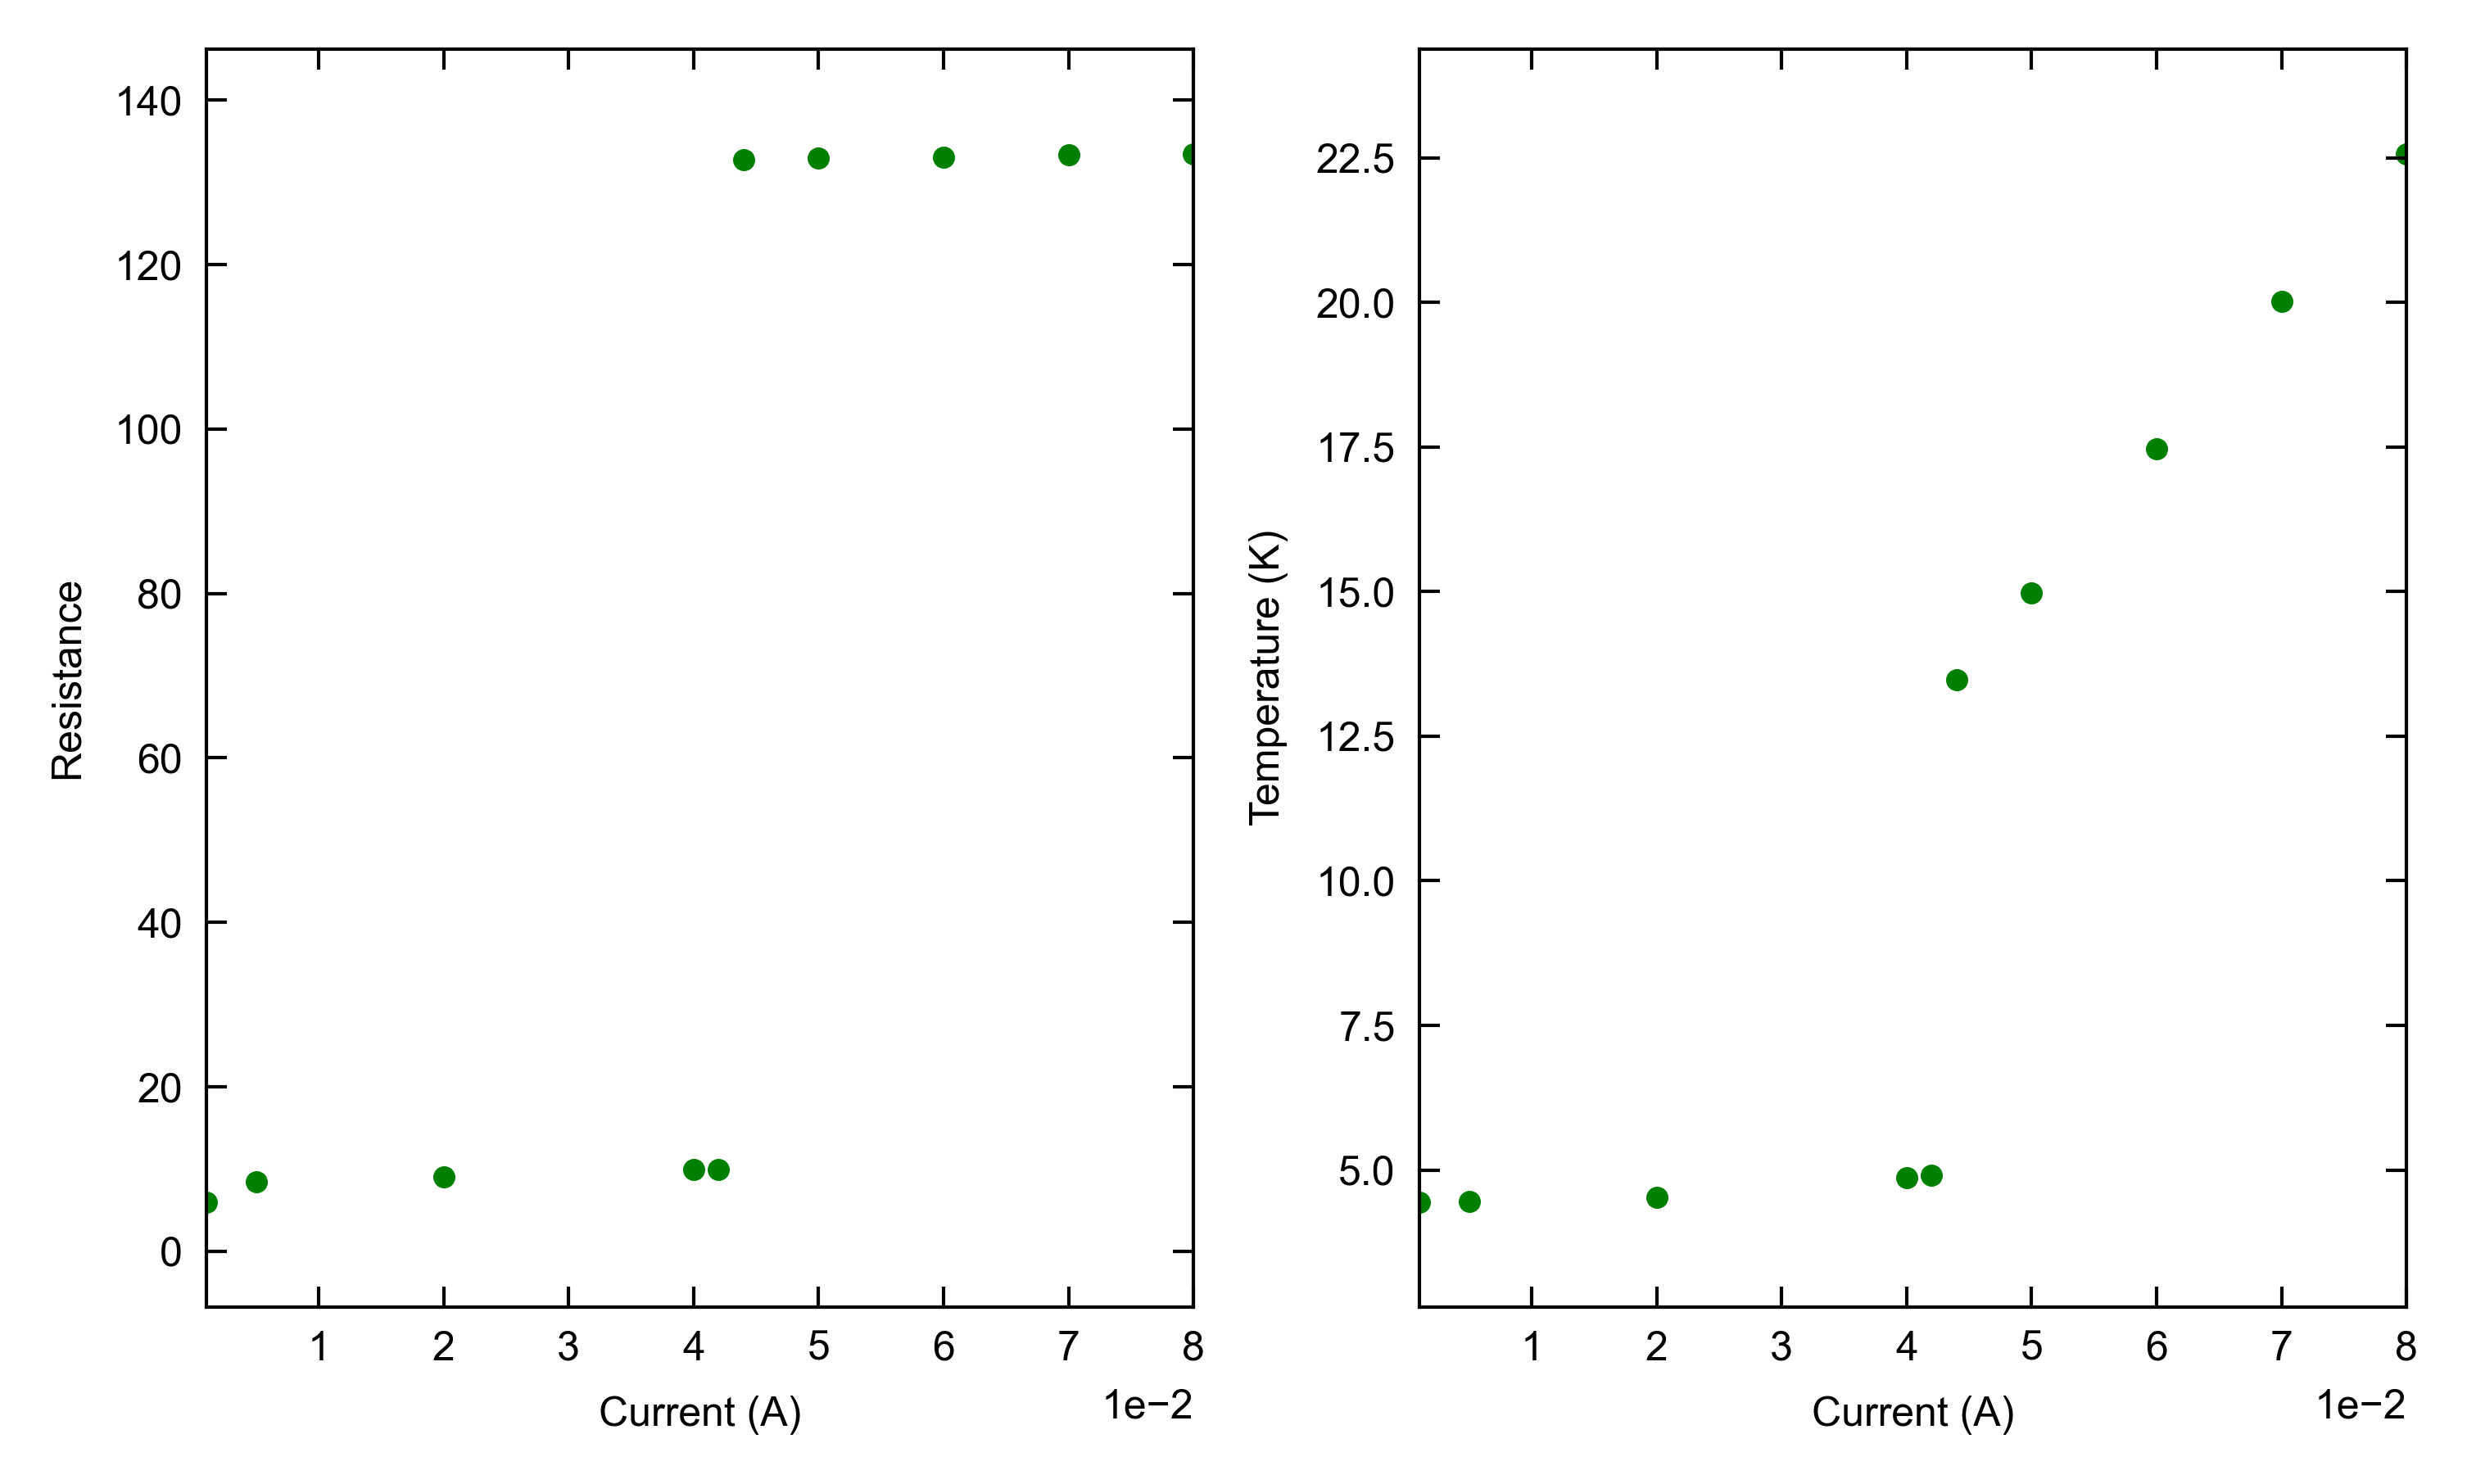

In [44]:
plt.figure(figsize = (5, 3))
plt.subplot(1, 2, 1)
plt.scatter(I_data, R_data, color = 'green', s = 5)
plt.xlabel('Current (A)')
plt.ylabel('Resistance')


plt.subplot(1, 2, 2)
plt.scatter(I_data,R2T_900(T_data), color = 'green', s = 5)
plt.xlabel('Current (A)')
plt.ylabel('Temperature (K)')
plt.show()

out of range: results may not be accurate


C:\Users\Crow108\AppData\Local\Temp\ipykernel_10404\3807678656.py:11: RuntimeWarning: divide by zero encountered in log
  log_T = np.log(T)


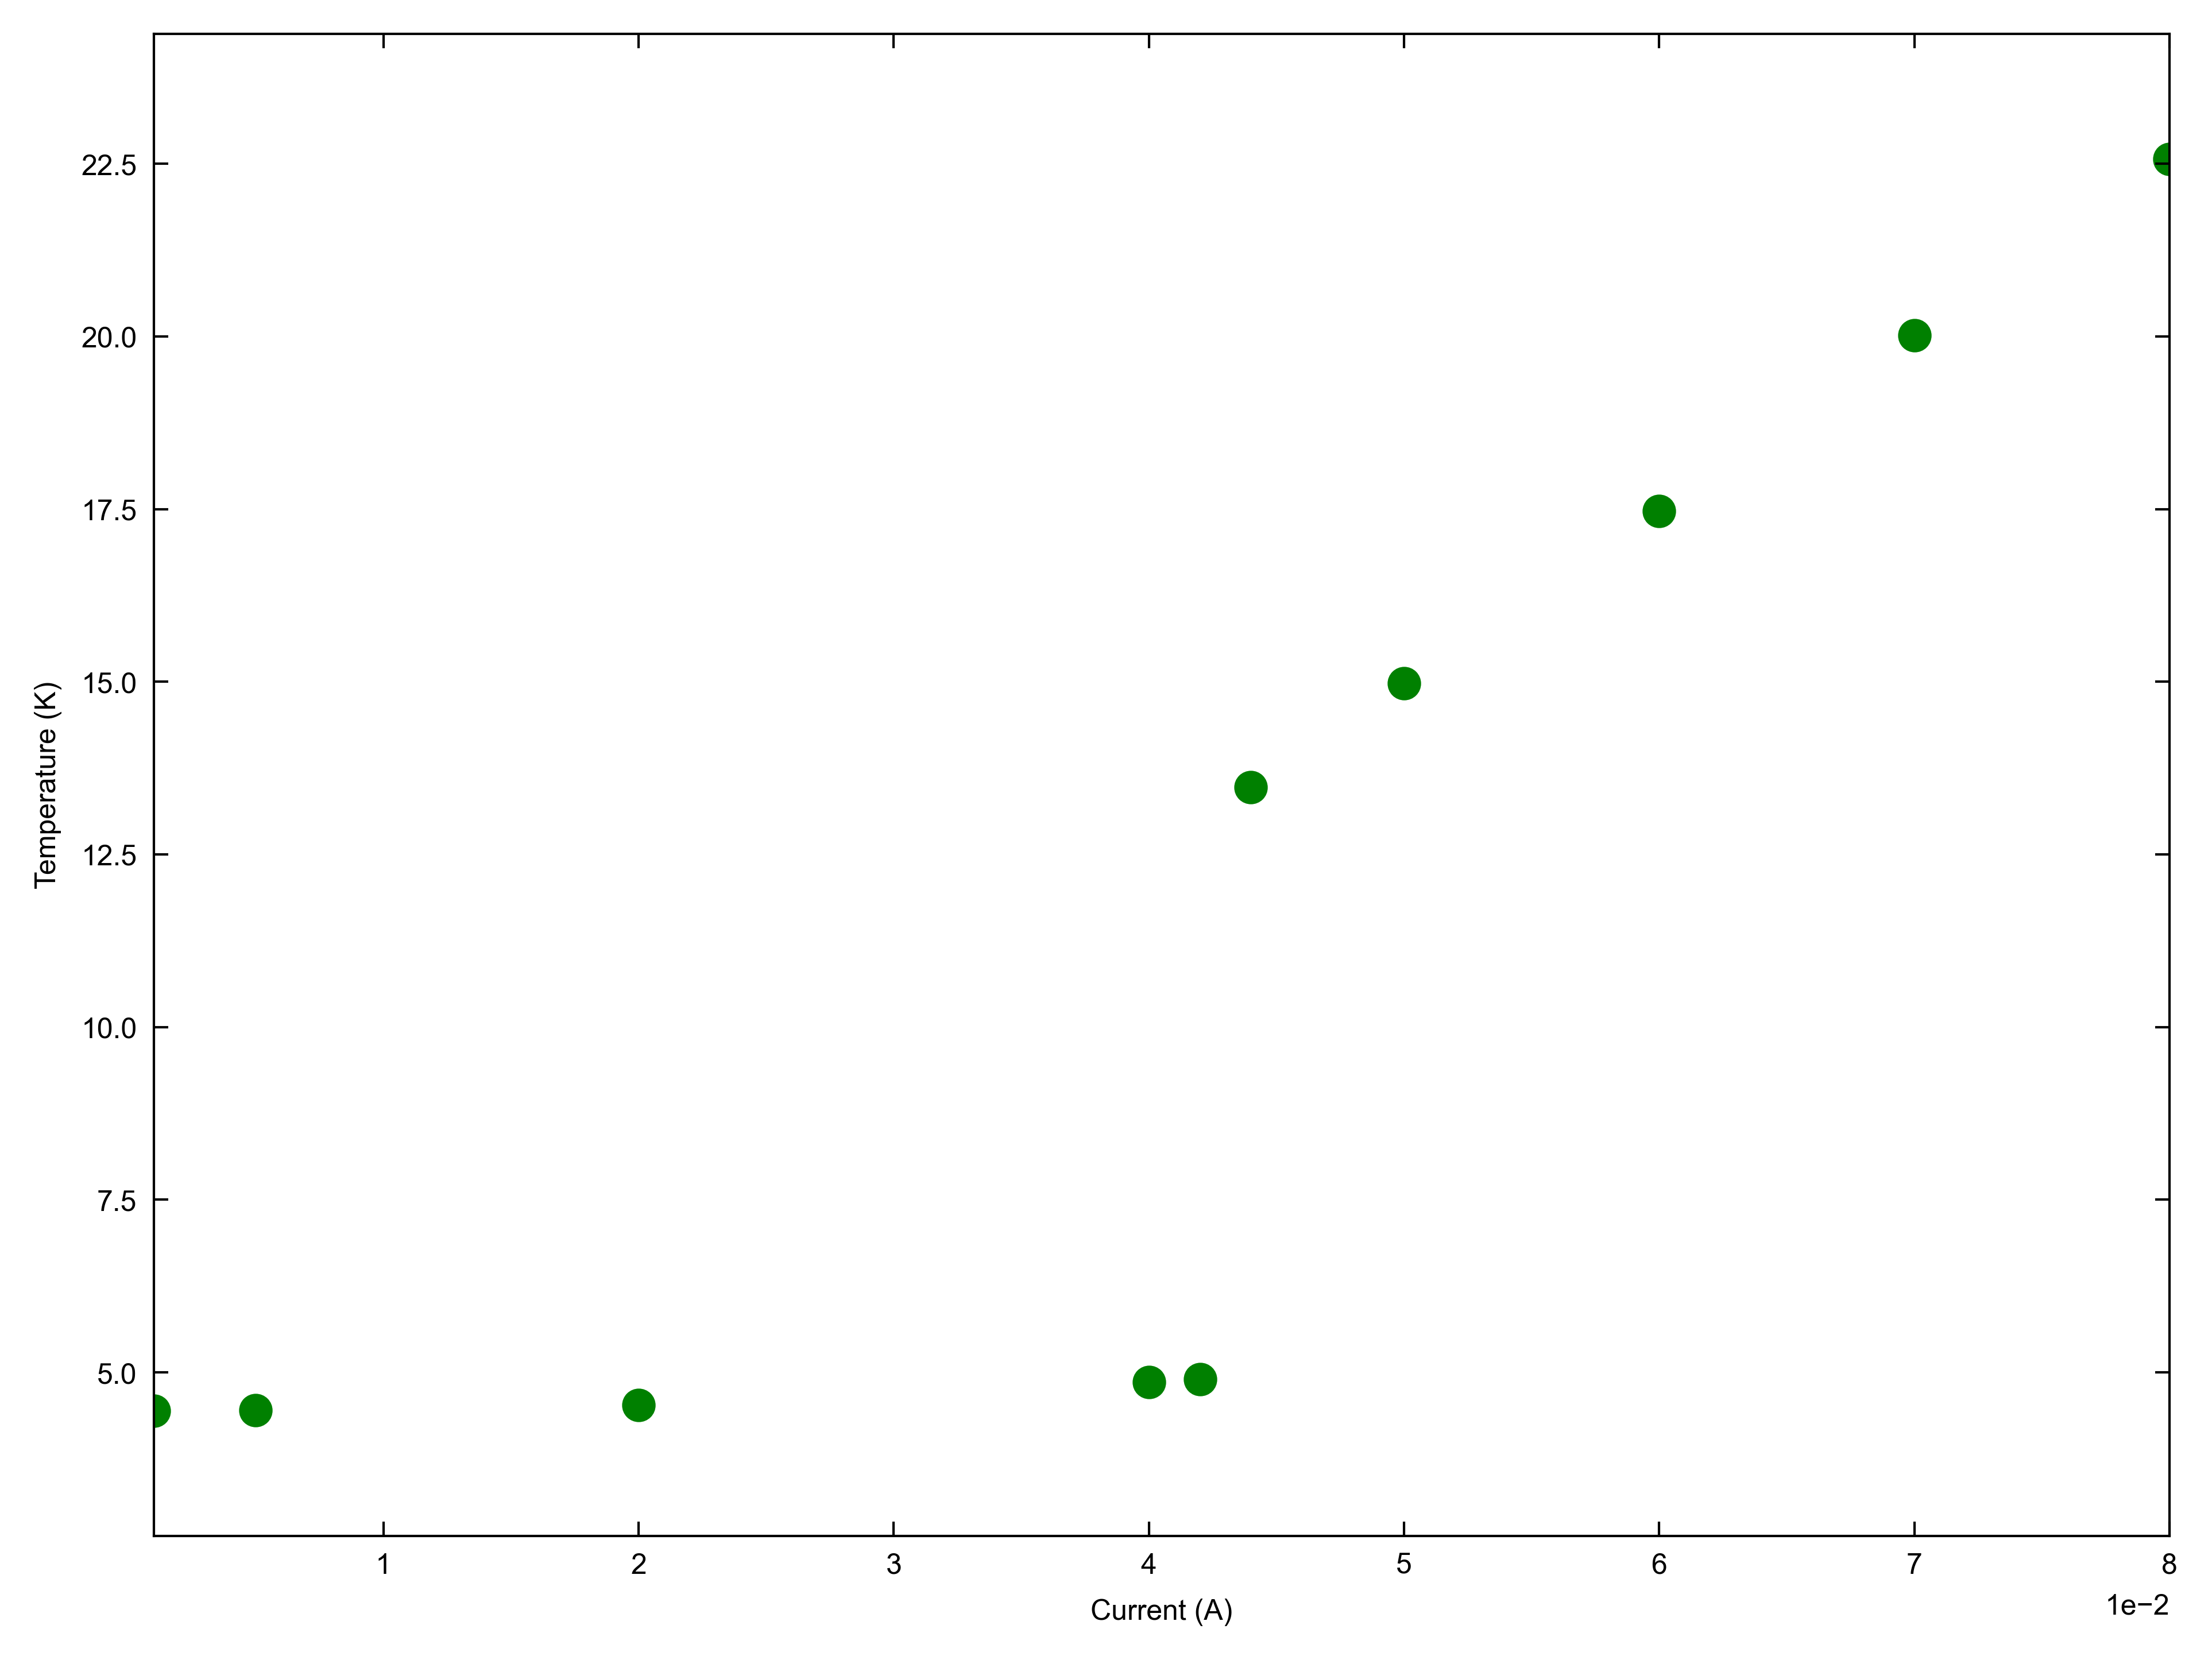

In [32]:
plt.scatter(I_data,R2T_900(T_data), color = 'green')
plt.xlabel('Current (A)')
plt.ylabel('Temperature (K)')
plt.show()